# Deep Learning with Keras and TensorFlow

# The Task for the AI

Our goal is to construct and train an artificial neural network on thousands of images of handwritten digits so that it may successfully identify others when presented. The data that will be incorporated is the MNIST database which contains 60,000 images for training and 10,000 test
images. We will use the Keras Python API with TensorFlow as the backend.

# Prerequisite Python Modules

First, some software needs to be loaded into the Python environment.


In [ ]:
import numpy as np # advanced math library
import matplotlib.pyplot as plt # MATLAB like plotting routines
import random # for generating random numbers
from keras.datasets import mnist # MNIST dataset is included in Keras
from keras.models import Sequential # Model type to be used
from keras.layers import Dense, Dropout, Activation # Import layers directly from keras.layers
from tensorflow.keras.utils import to_categorical  # Import to_categorical directly

# Replace any instances of 'np_utils.to_categorical' with 'to_categorical' in your code

# Loading Training Data

The MNIST dataset is conveniently bundled within Keras, and we can easily analyze some of its features in Python.

In [ ]:
# The MNIST data is split between 60,000 28 x 28 pixel training images and 10,000 28 x 28 pixel images
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("X_train shape", X_train.shape)
print("y_train shape", y_train.shape)
print("X_test shape", X_test.shape)
print("y_test shape", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape (60000, 28, 28)
y_train shape (60000,)
X_test shape (10000, 28, 28)
y_test shape (10000,)


Using matplotlib, we can plot some sample images from the training set directly into this Jupyter Notebook.

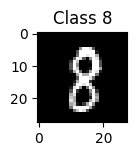

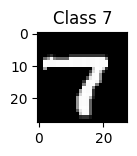

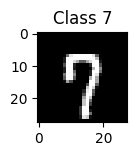

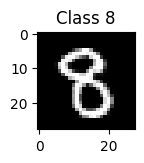

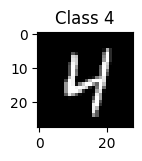

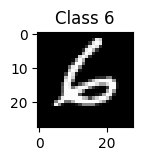

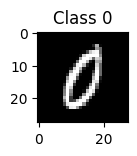

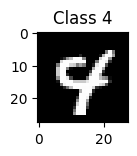

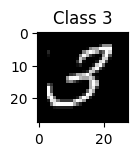

In [ ]:
plt.rcParams['figure.figsize'] = (4,4) # Make the figures a bit bigger
for i in range(9):
  plt.subplot(3,3,i+1)
  num = random.randint(0, len(X_train))
  plt.imshow(X_train[num], cmap='gray', interpolation='none')
  plt.title("Class {}".format(y_train[num]))
  plt.tight_layout()
  plt.show()

Let's examine a single digit a little closer, and print out the array representing the last digit.

In [ ]:
def matprint(mat, fmt="g"):
  col_maxes = [max([len(("{:"+fmt+"}").format(x)) for x in col]) for col in mat.T]
  for x in mat:
    for i, y in enumerate(x):
      print(("{:"+str(col_maxes[i])+fmt+"}").format(y), end="  ") # Print with two spaces
    print("") # New line after printing each row

# now print!
matprint(X_train[num])

Each pixel is an 8-bit integer from 0-255. 0 is full black, while 255 is full white. This what we call a single-channel pixel. It's called monochrome.


Fun-fact! Your computer screen has three channels for each pixel: red, green, blue. Each of these channels also likely takes an 8-bit integer. 3
channels -- 24 bits total -- 16,777,216 possible colors!

# Formatting the input data layer

Instead of a 28 x 28 matrix, we build our network to accept a 784-length vector.
Each image needs to be then reshaped (or flattened) into a vector. We'll also normalize the inputs to be in the range [0-1] rather than [0-255].
Normalizing inputs is generally recommended, so that any additional dimensions (for other network architectures) are of the same scale.

In [ ]:
X_train = X_train.reshape(60000, 784) # reshape 60,000 28 x 28 matrices into 60,000 784-length vectors.
X_test = X_test.reshape(10000, 784) # reshape 10,000 28 x 28 matrices into 10,000 784-length vectors.
X_train = X_train.astype('float32') # change integers to 32-bit floating point numbers
X_test = X_test.astype('float32')
X_train /= 255 # normalize each value for each pixel for the entire vector for each input
X_test /= 255
print("Training matrix shape", X_train.shape)
print("Testing matrix shape", X_test.shape)

Training matrix shape (60000, 784)
Testing matrix shape (10000, 784)


We then modify our classes (unique digits) to be in the one-hot format, i.e.

0 -> [1, 0, 0, 0, 0, 0, 0, 0, 0]




1 -> [0, 1, 0, 0, 0, 0, 0, 0, 0]

2 -> [0, 0, 1, 0, 0, 0, 0, 0, 0]

etc.

If the final output of our network is very close to one of these classes, then it is most likely that class. For example, if the final output is:

In [ ]:
[0, 0.94, 0, 0, 0, 0, 0.06, 0, 0]

then it is most probable that the image is that of the digit 1 .

In [ ]:
nb_classes = 10 # number of unique digits
# Use to_categorical directly instead of np_utils.to_categorical
Y_train = to_categorical(y_train, nb_classes)
Y_test = to_categorical(y_test, nb_classes)

# Building a 3-layer fully connected network (FCN)

Note: "fully connected" means every neuron in one layer is connected to every neuron in the next layer.

In [ ]:
layers = [
    # The first hidden layer is a set of 512 nodes (artificial neurons).
    # Each node will receive an element from each input vector and apply some weight and bias to it.
    Dense(512, input_shape=(784,), activation='relu'), #(784,) is not a typo -- that represents a 784 length vector!
    # An "activation" is a non-linear function applied to the output of the layer above.
    # It checks the new value of the node, and decides whether that artifical neuron has fired.
    # The Rectified Linear Unit (ReLU) converts all negative inputs to nodes in the next layer to be zero.
    # Those inputs are then not considered to be fired.
    # Positive values of a node are unchanged.



    # Dropout zeroes a selection of random outputs (i.e., disables their activation)
    # Dropout helps protect the model from memorizing or "overfitting" the training data.
    Dropout(0.2),

    # The second hidden layer appears identical to our first layer.
    # However, instead of each of the 512-node receiving 784-inputs from the input image data,
    # they receive 512 inputs from the output of the first 512-node layer.
    Dense(512, activation='relu'),
    Dropout(0.2),

    # The final layer of 10 neurons in fully-connected to the previous 512-node layer.
    # The final layer of a FCN should be equal to the number of desired classes (10 in this case).
    Dense(10, activation='softmax') # The "softmax" activation represents a probability distribution over K different possible outcomes; Its values are all non-negative and sum to 1.
]

# The Sequential model is a linear stack of layers and is very common.
model = Sequential(layers)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Summarize the built model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling the model

Keras is built on top of Theano and TensorFlow. Both packages allow you to define a computation graph in Python, which then compiles and
runs efficiently on the CPU or GPU without the overhead of the Python interpreter.
When compiing a model, Keras asks you to specify your loss function and your optimizer. The loss function we'll use here is called categorical
cross-entropy, and is a loss function well-suited to comparing two probability distributions.
Our predictions are probability distributions across the ten different digits (e.g. "we're 80% confident this image is a 3, 10% sure it's an 8, 5% it's
a 2, etc."), and the target is a probability distribution with 100% for the correct category, and 0 for everything else. The cross-entropy is a
measure of how different your predicted distribution is from the target distribution.
The optimizer helps determine how quickly the model learns through gradient descent. The rate at which descends a gradient is called the
learning rate.

So are smaller learning rates better? Not quite! It's important for an optimizer not to get stuck in local minima while neglecting the global
minimum of the loss function. Sometimes that means trying a larger learning rate to jump out of a local minimum.

In [ ]:
# Let's use the Adam optimizer for learning
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model!

This is the fun part!


The batch size determines over how much data per step is used to compute the loss function, gradients, and back propagation. Large batch
sizes allow the network to complete it's training faster; however, there are other factors beyond training speed to consider.
Too large of a batch size smoothes the local minima of the loss function, causing the optimizer to settle in one because it thinks it found the
global minimum.
Too small of a batch size creates a very noisy loss function, and the optimizer may never find the global minimum.
So a good batch size may take some trial and error to find!

In [ ]:
model.fit(X_train, Y_train,
batch_size=128, epochs=5,
verbose=1)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8625 - loss: 0.4540
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9689 - loss: 0.1029
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9767 - loss: 0.0726
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9818 - loss: 0.0540
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9856 - loss: 0.0455


The two numbers, in order, represent the value of the loss function of the network on the training set, and the overall accuracy of the network on
the training data. But how does it do on data it did not train on?


# Evaluate Model's Accuracy on Test Data

In [ ]:
score = model.evaluate(X_test, Y_test)
print('Test score:', score[0])
print('Test accuracy:', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9761 - loss: 0.0823
Test score: 0.07091373950242996
Test accuracy: 0.9793000221252441


## Inspecting the output

It's always a good idea to inspect the output and make sure everything looks sane. Here we'll look at some examples it gets right, and some
examples it gets wrong.

In [ ]:
# The predict_classes function outputs the highest probability class
# according to the trained classifier for each input example.
predicted_classes=np.argmax(model.predict(X_test) ,axis=1)
# Check which items we got right / wrong
correct_indices = np.nonzero(predicted_classes == y_test)[0]
incorrect_indices = np.nonzero(predicted_classes != y_test)[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


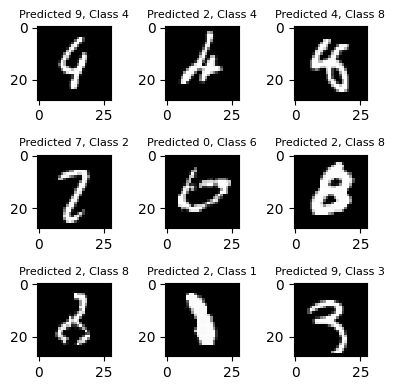

In [ ]:
plt.figure()
for i, incorrect in enumerate(incorrect_indices[:9]):
  plt.subplot(3,3,i+1)
  plt.imshow(X_test[incorrect].reshape(28,28), cmap='gray', interpolation='none')
  plt.title("Predicted {}, Class {}".format(predicted_classes[incorrect], y_test[incorrect]), fontsize=8) # Adjust fontsize as needed
plt.tight_layout()

In [ ]:
plt.figure()

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

Trying experimenting with the batch size! How does increasing the batch size to 10,000 affect the training time and test accuracy?
How about a batch size of 32?

# Introducing Convolution! What is it?

Before, we built a network that accepts the normalized pixel values of each value and operates solely on those values. What if we could instead
feed different features (e.g. curvature, edges) of each image into a network, and have the network learn which features are important for
classifying an image?
This possible through convolution! Convolution applies kernels (filters) that traverse through each image and generate feature maps.

In the above example, the image is a 5 x 5 matrix and the kernel going over it is a 3 x 3 matrix. A dot product operation takes place between the
image and the kernel and the convolved feature is generated. Each kernel in a CNN learns a different characteristic of an image.
Kernels are often used in photoediting software to apply blurring, edge detection, sharpening, etc.

Kernels in deep learning networks are used in similar ways, i.e. highlighting some feature. Combined with a system called max pooling, the non-
highlighted elements are discarded from each feature map, leaving only the features of interest, reducing the number of learned parameters,

and decreasing the computational cost (e.g. system memory).

We can also take convolutions of convolutions -- we can stack as many convolutions as we want, as long as there are enough pixels to fit a
kernel.
Warning: What you may find down there in those deep convolutions may not appear recognizable to you.

## Building a "Deep" Convolutional Neural Network

In [ ]:
# import some additional tools
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Use tensorflow.keras instead of keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, ZeroPadding2D, GlobalAveragePooling2D, Flatten # Use tensorflow.keras instead of keras
from tensorflow.keras.layers import BatchNormalization # Use tensorflow.keras instead of keras

In [ ]:
# Reload the MNIST data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [ ]:
# Again, do some formatting
# Except we do not flatten each image into a 784-length vector because we want to perform convolutions first
X_train = X_train.reshape(60000, 28, 28, 1) #add an additional dimension to represent the single-channel
X_test = X_test.reshape(10000, 28, 28, 1)
X_train = X_train.astype('float32') # change integers to 32-bit floating point numbers
X_test = X_test.astype('float32')
X_train /= 255 # normalize each value for each pixel for the entire vector for each input
X_test /= 255
print("Training matrix shape", X_train.shape)
print("Testing matrix shape", X_test.shape)

Training matrix shape (60000, 28, 28, 1)
Testing matrix shape (10000, 28, 28, 1)


In [ ]:
# one-hot format classes
!pip install tensorflow
from tensorflow.keras.utils import to_categorical # Import to_categorical from tensorflow.keras.utils
nb_classes = 10 # number of unique digits
Y_train = to_categorical(y_train, nb_classes) # Use to_categorical directly
Y_test = to_categorical(y_test, nb_classes) # Use to_categorical directly
model = Sequential() # Linear stacking of layers

In [ ]:
model = Sequential([
    # Convolution Layer 1
    Conv2D(32, (3, 3), input_shape=(28, 28, 1), activation='relu'), # 32 different 3x3 kernels -- so 32 feature maps # activation
    # normalize each feature map before activation
    BatchNormalization(axis=-1),

    # Convolution Layer 2
    Conv2D(32, (3, 3), activation='relu'), # 32 different 3x3 kernels -- so 32 feature maps # activation
    # normalize each feature map before activation
    BatchNormalization(axis=-1),
    # Pool the max values over a 2x2 kernel
    MaxPooling2D(pool_size=(2, 2)),

    # Convolution Layer 3
    Conv2D(64, (3, 3), activation='relu'), # 64 different 3x3 kernels -- so 64 feature maps
    BatchNormalization(axis=-1), # normalize each feature map

    # Convolution Layer 4
    Conv2D(64, (3, 3), activation='relu'), # 64 different 3x3 kernels -- so 64 feature maps
    BatchNormalization(axis=-1), # normalize each feature map
    MaxPooling2D(pool_size=(2, 2)), # Pool the max values over a 2x2 kernel
    Flatten(),

    # Fully Connected Layer 5
    Dense(512, activation='relu'), # 512 FCN nodes
    BatchNormalization(), # normalization

    # Fully Connected Layer 6
    Dropout(0.2), # 20% dropout of randomly selected nodes
    Dense(10, activation='softmax') # final 10 FCN nodes
])

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 26, 26, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 26, 26, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 24, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 24, 24, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 10, 10, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 10, 10, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 8, 8, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 4, 4, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │              

 Total params: 597,738 (2.28 MB)

 Trainable params: 596,330 (2.27 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
# we'll use the same optimizer
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# data augmentation prevents overfitting by slightly changing the data randomly
# Keras has a great built-in feature to do automatic augmentation
gen = ImageDataGenerator(rotation_range=8, width_shift_range=0.08, shear_range=0.3,

height_shift_range=0.08, zoom_range=0.08)

test_gen = ImageDataGenerator()

In [ ]:
# We can then feed our augmented data in batches
# Besides loss function considerations as before, this method actually results in significant memory savings
# because we are actually LOADING the data into the network in batches before processing each batch
# Before the data was all loaded into memory, but then processed in batches.
train_generator = gen.flow(X_train, Y_train, batch_size=128)
test_generator = test_gen.flow(X_test, Y_test, batch_size=128)

In [ ]:
# note: this chunk took me ~10mins to run
# We can now train our model which is fed data by our batch loader
# Steps per epoch should always be total size of the set divided by the batch size
# SIGNIFICANT MEMORY SAVINGS (important for larger, deeper networks)
model.fit(train_generator, steps_per_epoch=60000//128, epochs=5, verbose=1,
          validation_data=test_generator, validation_steps=10000//128)

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


468/468 ━━━━━━━━━━━━━━━━━━━━ 184s 384ms/step - accuracy: 0.9111 - loss: 0.2795 - val_accuracy: 0.9829 - val_loss: 0.0533
Epoch 2/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 133us/step - accuracy: 0.9844 - loss: 0.0878 - val_accuracy: 1.0000 - val_loss: 0.0290
Epoch 3/5


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


468/468 ━━━━━━━━━━━━━━━━━━━━ 197s 374ms/step - accuracy: 0.9831 - loss: 0.0539 - val_accuracy: 0.9876 - val_loss: 0.0392
Epoch 4/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9766 - loss: 0.0579 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 5/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 176s 375ms/step - accuracy: 0.9878 - loss: 0.0387 - val_accuracy: 0.9906 - val_loss: 0.0282


In [ ]:
score = model.evaluate(X_test, Y_test)
print('Test score:', score[0])
print('Test accuracy:', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.9856 - loss: 0.0373
Test score: 0.02824246510863304
Test accuracy: 0.9905999898910522
